### 🔄️ What is Iterative Retrieval in Agentic RAG?

#### Combined both Iterative and Self Reflection

✅ Definition: Iterative Retrieval is a dynamic strategy where an AI agent doesn't settle for the first batch of retrieved documents.
instead, it evaluates the adequacy of the initial context and if necessary it:

- Refines the query,
- Retrieves again,
- Repeats the process until it's confident enough to answer the original question.

🧠 Why use it? In standard RAG:
- A single retrieval step is done and the LLM uses it to answer.
- If the documents were incomplete or irrelevant, the answer may fail.

In Iterative RAG:
- The agent reflects on the retrieved content and the answer it produced.
- If it's unsure, it can refine its search (like a human researcher would).

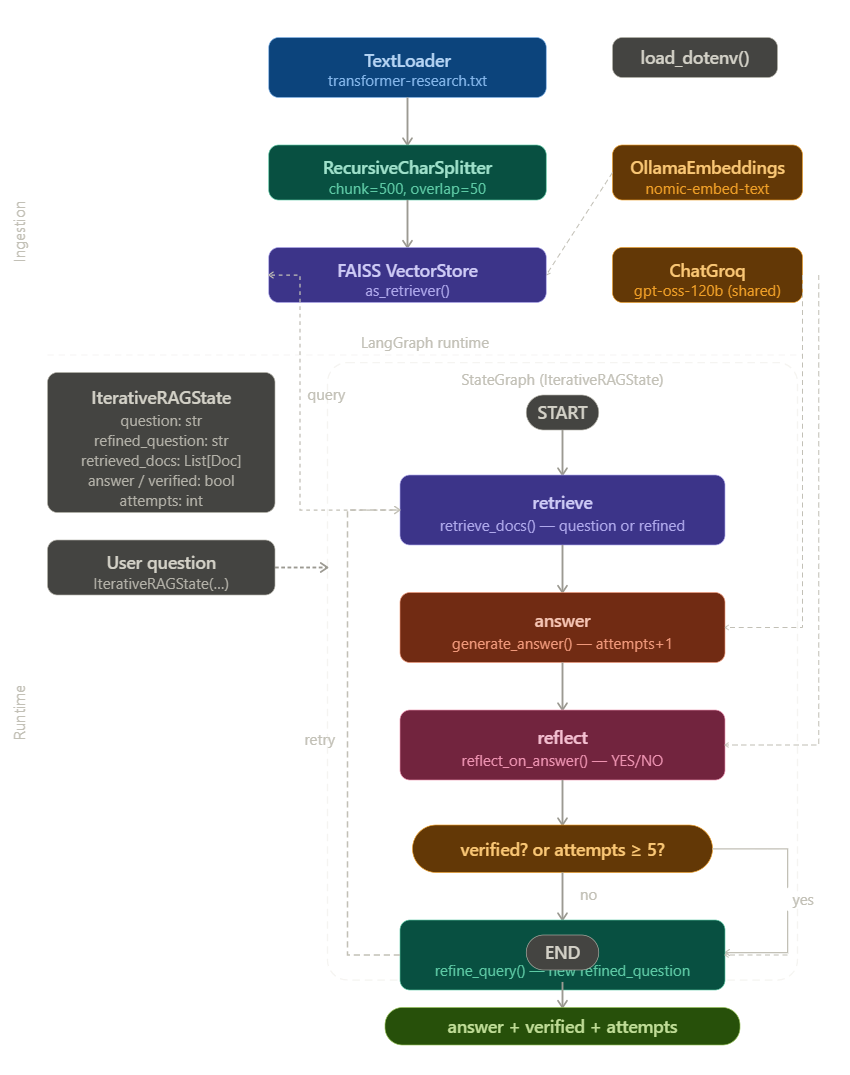

In [1]:
# ------------------------------------------------------------
# 1. Load Text File, Embeddings, Vector Store and LLM 
# ------------------------------------------------------------

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq

import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

docs = TextLoader('data/transformer-research.txt', encoding='utf-8').load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

embedding = OllamaEmbeddings(model='nomic-embed-text')

vector_store = FAISS.from_documents(chunks, embedding)
retriever = vector_store.as_retriever()

llm = ChatGroq(model='openai/gpt-oss-120b')

In [2]:
# ------------------------------------------------------------
# 2. LangGraph State Definition 
# ------------------------------------------------------------

from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document

class IterativeRAGState(BaseModel):
    question: str
    refined_question: str = ''
    retrieved_docs: List[Document] = []
    answer: str = ''
    verified: bool = False
    attempts: int = 0

In [ ]:
# ------------------------------------------------------------
# 3. Nodes 
# ------------------------------------------------------------

# a) Retriever Documents
def retrieve_docs(state: IterativeRAGState) -> IterativeRAGState:
    query = state.question or state.refined_question
    doc = retriever.invoke(query)
    return state.model_copy(update={'retrieved_docs': doc})

# b) Generate Answer
def generate_answer(state: IterativeRAGState) -> IterativeRAGState:
    context = '\n\n'.join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""
        Use the following context to answer the question:
        
        Context: {context}
        Question: {state.question}
    """
    response = llm.invoke(prompt).content
    return state.model_copy(update={'answer': response, 'attempts': state.attempts + 1})

# c) Reflect Answer
def reflect_on_answer(state: IterativeRAGState) -> IterativeRAGState:
    prompt = f"""
        Evaluate whether the answer below is factually sufficient and complete.
        
        Question: {state.question}
        Answer: {state.answer}
        
        Respond 'YES' if it's complete, otherwise 'NO' with feedback.
    """
    feedback = llm.invoke(prompt).content.lower()
    verified = 'yes' in feedback
    return state.model_copy(update={'verified': verified})

# d) Refine Query
def refine_query(state: IterativeRAGState) -> IterativeRAGState:
    prompt = f"""
        The answer appears incomplete. Suggest a better version of the query that would help retrieve more relevant context.
        
        Original Question: {state.question}
        Current Answer: {state.answer}
    """
    new_query = llm.invoke(prompt).content.strip()
    return state.model_copy(update={'refined_question': new_query})

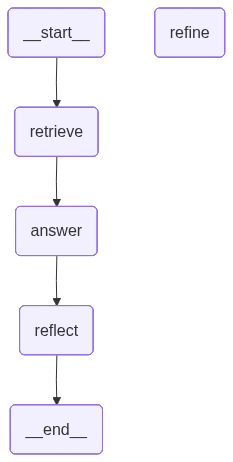

In [7]:
# ------------------------------------------------------------
# 4. LangGraph 
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(IterativeRAGState)

builder.add_node('retrieve', retrieve_docs)
builder.add_node('answer', generate_answer)
builder.add_node('reflect', reflect_on_answer)
builder.add_node('refine', refine_query)

builder.set_entry_point('retrieve')
builder.add_edge('retrieve', 'answer')
builder.add_edge('answer', 'reflect')
builder.add_conditional_edges(
    'reflect',
    lambda s: END if s.verified or s.attempts >= 5 else 'refine'
)
builder.add_edge('refine', 'retrieve')
builder.add_edge('answer', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# ------------------------------------------------------------
# 5. Run the Agent 
# ------------------------------------------------------------

if __name__ == '__main__':
    query = 'What are the transformer variants in production deployments?'
    state = IterativeRAGState(question=query)
    result = graph.invoke(state)
    
    print('\n ✅ Final Answer: \n', result['answer'])
    print('\n 🧠 Verified: ', result['verified'])
    print('\n 🔄️ Total Attempts: ', result['attempts'])


 ✅ Final Answer: 
 **Transformer variants that are currently being used (or are ready) for production‑grade deployments, according to the experiment log:**

| Variant | Typical production use‑case / deployment target | Key notes from the log |
|---------|-----------------------------------------------|------------------------|
| **EfficientFormer** | Edge inference (e.g., Raspberry Pi 4) | 92.4 % top‑1 on TinyImageNet, ~290 MB memory at batch‑size 16, works well in int8 quantised mode with negligible accuracy loss. |
| **Longformer** | Long‑context workloads such as customer‑support chat logs (up to 8 k tokens) | Handles very long sequences; latency >1.2 s in streaming mode, but chunk‑based hybrid attention can trim delay. |
| **TinyBERT** | Lightweight classification (support‑ticket priority tagging) | 87 % F1, fine‑tuned with a 2‑layer FFN adapter for domain transfer; good for on‑device or low‑latency services. |
| **LLaMA 2** (augmented with **FlashAttention 2**) | High‑throughput 